In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import geopandas as gpd
import seaborn as sns

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from xgboost import plot_importance

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
df = pd.read_csv('telecom_churn.csv')

In [3]:
##the pupose of this project is to predict customer churn for a telecom company. 'df' will be the associated data frame. 
##The data was taken from kaggle. 
##Specifically, this project will focus on comparing results from a linear baseline model, tree based model, and deep learning model. 

In [4]:
# TODO: Start EDA Process

In [5]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df['Churn'] = df['Churn'].replace({False: 0, True: 1})

C:\Users\matth\AppData\Local\Temp\ipykernel_15864\3547494869.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({False: 0, True: 1})


In [7]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [9]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,0.144914
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,0.352067
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,0.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


In [10]:
df_state = df['State'].value_counts()
df_state.shape[0]

51

In [11]:
df_state.head()

State
WV    106
MN     84
NY     83
AL     80
OH     78
Name: count, dtype: int64

In [12]:
df_zip = df['Area code'].value_counts()
df_zip.shape[0]

3

In [13]:
df_zip.head()

Area code
415    1655
510     840
408     838
Name: count, dtype: int64

In [14]:
##Because there are so many less area codes than states, it will probably be much easier to work with area codes.

In [15]:
df.groupby('Area code').agg(customer_churn=('Churn', 'sum')).reset_index()

,Area code,customer_churn
0,408,122
1,415,236
2,510,125


In [16]:
##Customers in Area code 415 represent around half of the total customer churn

In [17]:
df['International plan'].value_counts()

International plan
No     3010
Yes     323
Name: count, dtype: int64

In [18]:
df.groupby('International plan').agg(customer_churn=('Churn', 'sum')).reset_index()

,International plan,customer_churn
0,No,346
1,Yes,137


In [19]:
##customers who dont have an international plan tend to churn at a rate that is about twice as much as customers who do not. 

In [20]:
df['Voice mail plan'].value_counts()

Voice mail plan
No     2411
Yes     922
Name: count, dtype: int64

In [21]:
df.groupby('Voice mail plan').agg(customer_churn=('Churn', 'sum')).reset_index()

,Voice mail plan,customer_churn
0,No,403
1,Yes,80


In [22]:
df.groupby('Number vmail messages').agg(customer_churn=('Churn', 'sum')).reset_index()

,Number vmail messages,customer_churn
0,0,403
1,4,0
2,8,0
3,9,0
4,10,0
5,11,0
6,12,0
7,13,0
8,14,0
9,15,1


In [23]:
##Interestingly, it seems that customers with no voice mail plan churn more than 5x more than customers who do

In [24]:
display(df.groupby('International plan').agg(day_minutes=('Total day minutes', 'mean'), customer_churn=('Churn', 'sum')).reset_index())
display(df.groupby('Voice mail plan').agg(day_minutes=('Total day minutes', 'mean'), customer_churn=('Churn', 'sum')).reset_index())

,International plan,day_minutes,customer_churn
0,No,178.893887,346
1,Yes,187.986997,137


,Voice mail plan,day_minutes,customer_churn
0,No,179.831813,403
1,Yes,179.626790,80


In [25]:
##Since International plan and Voice mail plan both seem to have inordinate levels of churn associated to them, they are compared to numerical columns. Looking at day minutes, 
##day minutes does not seem to have a significant impact on churn

In [26]:
display(df.groupby('International plan').agg(day_minutes=('Total day minutes', 'mean'),
                                             day_calls=('Total day calls', 'mean'), day_charge=('Total day charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())
display(df.groupby('Voice mail plan').agg(day_minutes=('Total day minutes', 'mean'),
                                             day_calls=('Total day calls', 'mean'), day_charge=('Total day charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())

,International plan,day_minutes,day_calls,day_charge,customer_churn
0,No,178.893887,100.410963,30.412495,346
1,Yes,187.986997,100.665635,31.958390,137


,Voice mail plan,day_minutes,day_calls,day_charge,customer_churn
0,No,179.831813,100.573206,30.571958,403
1,Yes,179.626790,100.075922,30.537072,80


In [27]:
##As stated above, Customers who have no voice mail plan, typicall churn 5x more than customers who do. This metric does not seem at all impacted by customer day activity, as the tables
##shown directly above, where the day activity is almost the same for customers with and without voice mail plans. However, for customers with no international plans, day minutes and day
##charges are noticably lower, while they are making approximately the same volume of calls.

In [28]:
display(df.groupby('International plan').agg(eve_minutes=('Total eve minutes', 'mean'),
                                             eve_calls=('Total eve calls', 'mean'), eve_charge=('Total eve charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())
display(df.groupby('Voice mail plan').agg(eve_minutes=('Total eve minutes', 'mean'),
                                             eve_calls=('Total eve calls', 'mean'), eve_charge=('Total eve charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())

,International plan,eve_minutes,eve_calls,eve_charge,customer_churn
0,No,200.663090,100.074419,17.056565,346
1,Yes,203.936842,100.486068,17.334923,137


,Voice mail plan,eve_minutes,eve_calls,eve_charge,customer_churn
0,No,200.304770,100.193696,17.026080,403
1,Yes,202.746963,99.906725,17.233796,80


In [29]:
##For eve minutes, the trend seems to repeat itself for International plan. Customers with no international plan tend to use the service less despite making a similar number of calls.
##Now the story starts to change with Voice mail plan, customers with no voice mail plan, who churn at a 5x rate, tend to use talk on the phone less at night, despit making approximatley
##the same number of calls. The trend somewhat starts to mimick that of the international plan

In [30]:
display(df.groupby('International plan').agg(night_minutes=('Total night minutes', 'mean'),
                                             night_calls=('Total night calls', 'mean'), night_charge=('Total night charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())
display(df.groupby('Voice mail plan').agg(night_minutes=('Total night minutes', 'mean'),
                                             night_calls=('Total night calls', 'mean'), night_charge=('Total night charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index())

,International plan,night_minutes,night_calls,night_charge,customer_churn
0,No,201.350831,100.027907,9.060877,346
1,Yes,196.410217,100.851393,8.838483,137


,Voice mail plan,night_minutes,night_calls,night_charge,customer_churn
0,No,200.681958,99.919535,9.030792,403
1,Yes,201.369089,100.599783,9.061638,80


In [31]:
##Customers with international plans show a clear difference by how much they use the service at night. On average, they are spending 5 more minutes/month, while making the same
##number of calls and generating almost the same charge. On average, customers with no voice mail plan are using the service for almost a minute less at night, making almost one less call
##per night, and generating almost the same charge as someone who does have  a voice mail plan.

In [32]:
df.groupby('International plan').agg(total_minutes=('Total intl minutes', 'mean'), total_intl_calls=('Total intl calls', 'mean'), 
                                     total_intl_charge=('Total intl charge', 'mean'), customer_churn=('Churn', 'sum')).reset_index()

,International plan,total_minutes,total_intl_calls,total_intl_charge,customer_churn
0,No,10.195349,4.465449,2.753279,346
1,Yes,10.628173,4.609907,2.869907,137


In [33]:
##On average, it seems that customers with an international plan vs those without have comparable usage of international services. The larges average discrepancies come from total
##intl minutes, with is approximatley 0.43 minutes less per month without an international plan and total international charge, which is only about 0.1 less with international plan

In [34]:
df['Customer service calls'].value_counts()

Customer service calls
1    1181
2     759
0     697
3     429
4     166
5      66
6      22
7       9
9       2
8       2
Name: count, dtype: int64

In [35]:
df['International plan'] = df['International plan'].replace({'Yes':1, 'No':0})
df ['Voice mail plan']= df['Voice mail plan'].replace({'Yes':1, 'No':0})
df_service_calls_churn = df.groupby('Customer service calls').agg(total_customer=('Churn', 'count'), itl_plan=('International plan', 'sum'), voice_mail_plan=('Voice mail plan', 'sum'),
                                                                  customer_churn=('Churn', 'sum')).reset_index()
df_service_calls_churn['Churn_rate'] = ((df_service_calls_churn['customer_churn']/df_service_calls_churn['total_customer'])*100).round(2)
df_service_calls_churn

C:\Users\matth\AppData\Local\Temp\ipykernel_15864\28311977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['International plan'] = df['International plan'].replace({'Yes':1, 'No':0})
C:\Users\matth\AppData\Local\Temp\ipykernel_15864\28311977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df ['Voice mail plan']= df['Voice mail plan'].replace({'Yes':1, 'No':0})


,Customer service calls,total_customer,itl_plan,voice_mail_plan,customer_churn,Churn_rate
0,0,697,83,193,92,13.20
1,1,1181,112,344,122,10.33
2,2,759,62,215,87,11.46
3,3,429,38,98,44,10.26
4,4,166,21,42,76,45.78
5,5,66,6,17,40,60.61
6,6,22,0,9,14,63.64
7,7,9,0,2,5,55.56
8,8,2,0,1,1,50.00
9,9,2,1,1,2,100.00


In [36]:
##clearly, with increase in number of customer service calls, chrun rate increases. The first most noteable jumps occur in at 4 calls when the churn rate jumps from 10.26% to 45.78%. 
##In addition, the churn rate also jumps from 50-100% moving from 8 calls to 9 calls. Included are internal plan and voice mail plan monicers for churn, but these are less useful
##than initially intended.

In [37]:
# TODO Understand numerical data

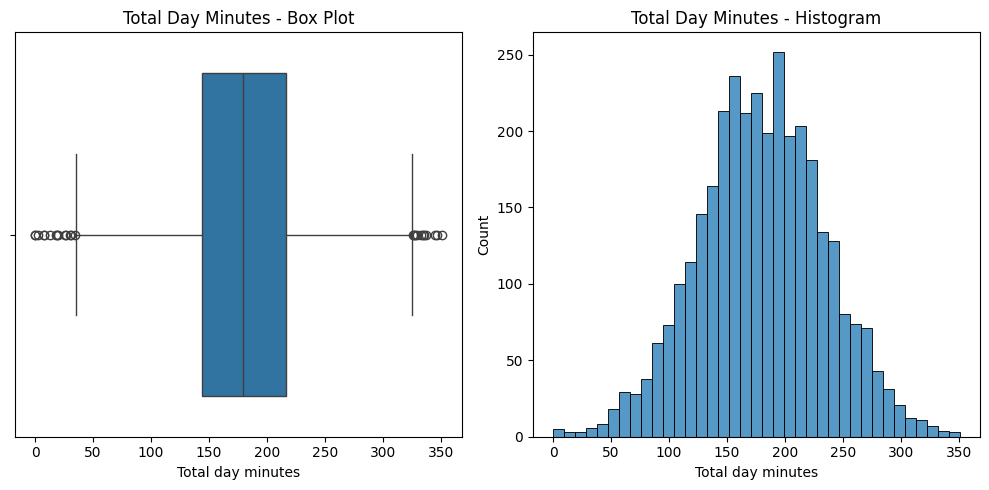

In [38]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total day minutes'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total day minutes'],
    ax=axes[1]
)

axes[0].set_title('Total Day Minutes - Box Plot')
axes[1].set_title('Total Day Minutes - Histogram')

plt.tight_layout()
plt.show()

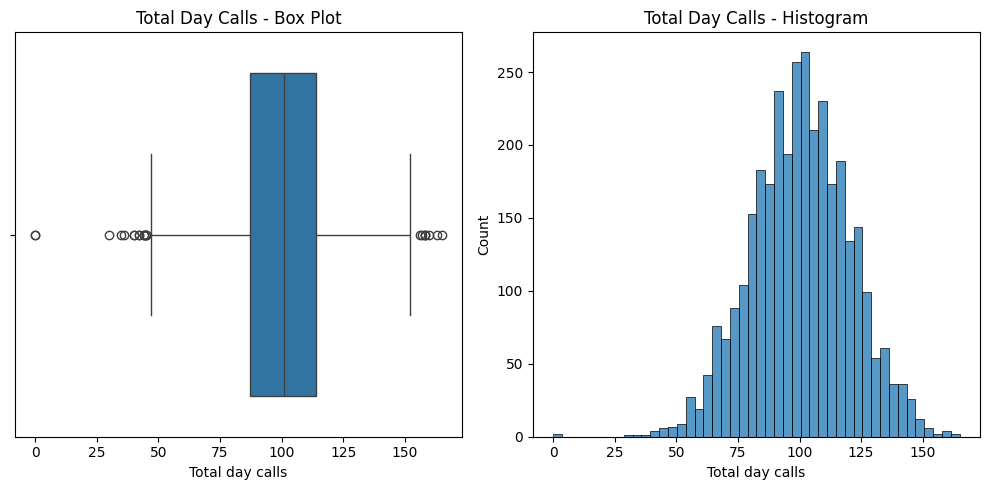

In [39]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total day calls'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total day calls'],
    ax=axes[1]
)

axes[0].set_title('Total Day Calls - Box Plot')
axes[1].set_title('Total Day Calls - Histogram')

plt.tight_layout()
plt.show()

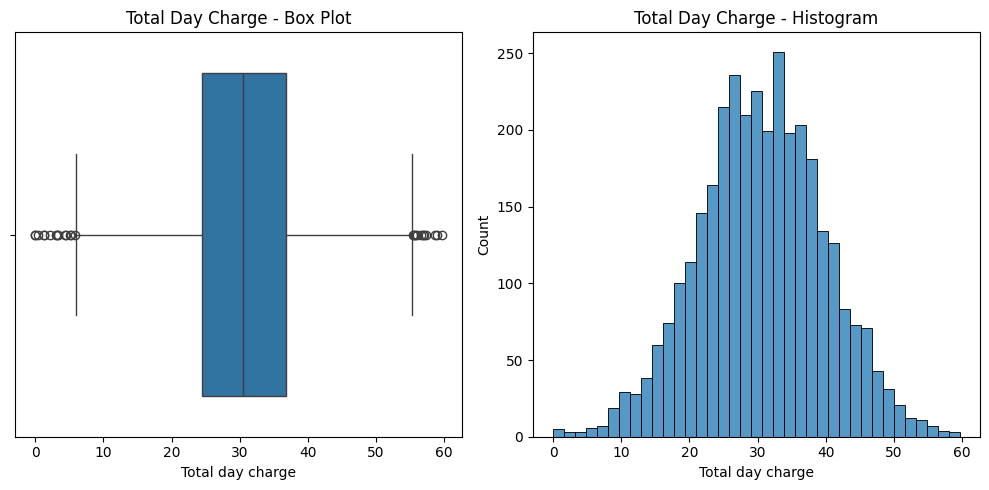

In [40]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total day charge'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total day charge'],
    ax=axes[1]
)

axes[0].set_title('Total Day Charge - Box Plot')
axes[1].set_title('Total Day Charge - Histogram')

plt.tight_layout()
plt.show()

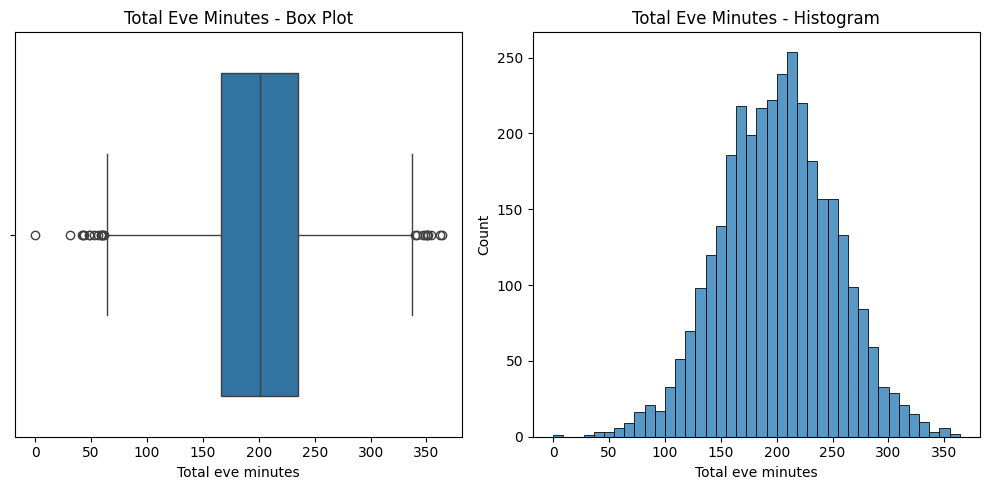

In [41]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total eve minutes'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total eve minutes'],
    ax=axes[1]
)

axes[0].set_title('Total Eve Minutes - Box Plot')
axes[1].set_title('Total Eve Minutes - Histogram')

plt.tight_layout()
plt.show()

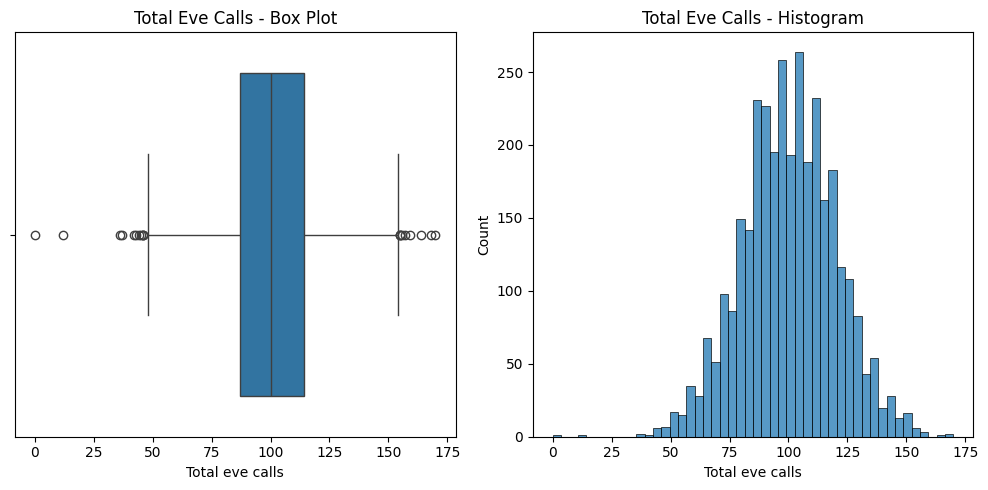

In [42]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total eve calls'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total eve calls'],
    ax=axes[1]
)

axes[0].set_title('Total Eve Calls - Box Plot')
axes[1].set_title('Total Eve Calls - Histogram')

plt.tight_layout()
plt.show()

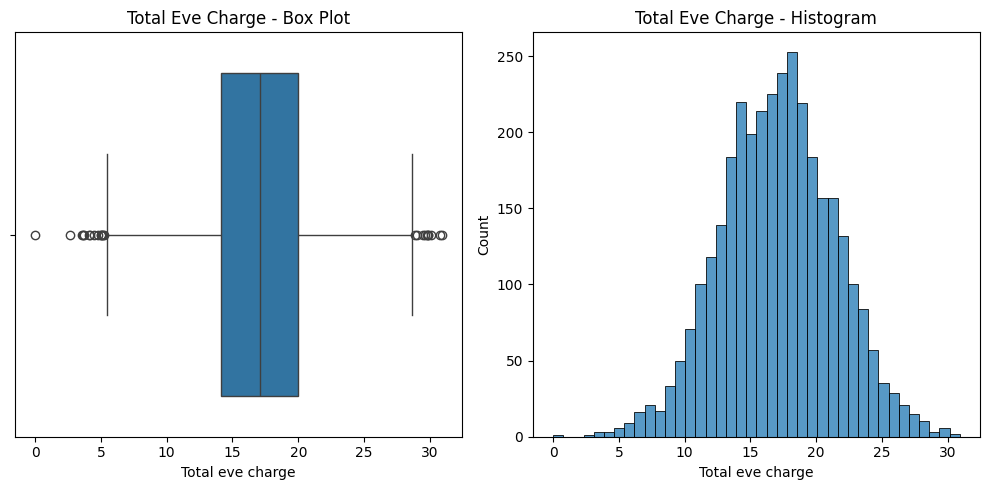

In [43]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total eve charge'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total eve charge'],
    ax=axes[1]
)

axes[0].set_title('Total Eve Charge - Box Plot')
axes[1].set_title('Total Eve Charge - Histogram')

plt.tight_layout()
plt.show()

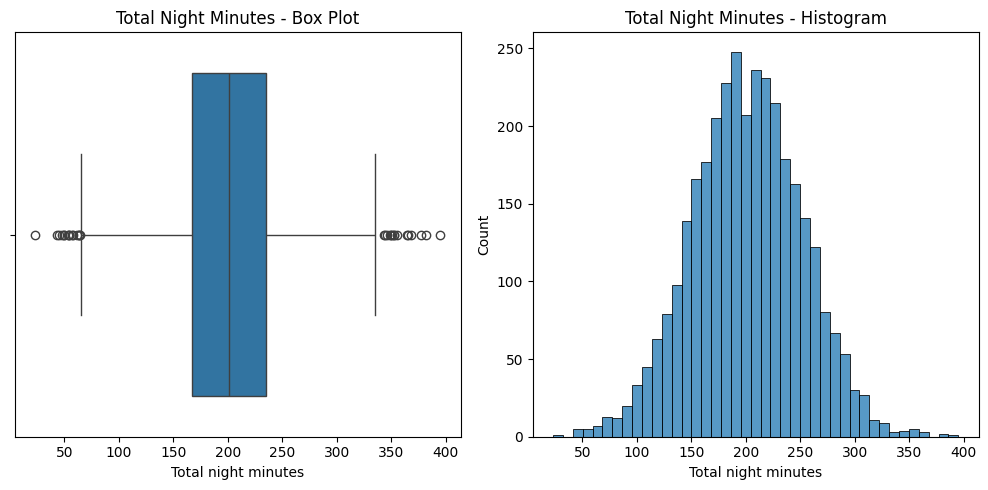

In [44]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total night minutes'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total night minutes'],
    ax=axes[1]
)

axes[0].set_title('Total Night Minutes - Box Plot')
axes[1].set_title('Total Night Minutes - Histogram')

plt.tight_layout()
plt.show()

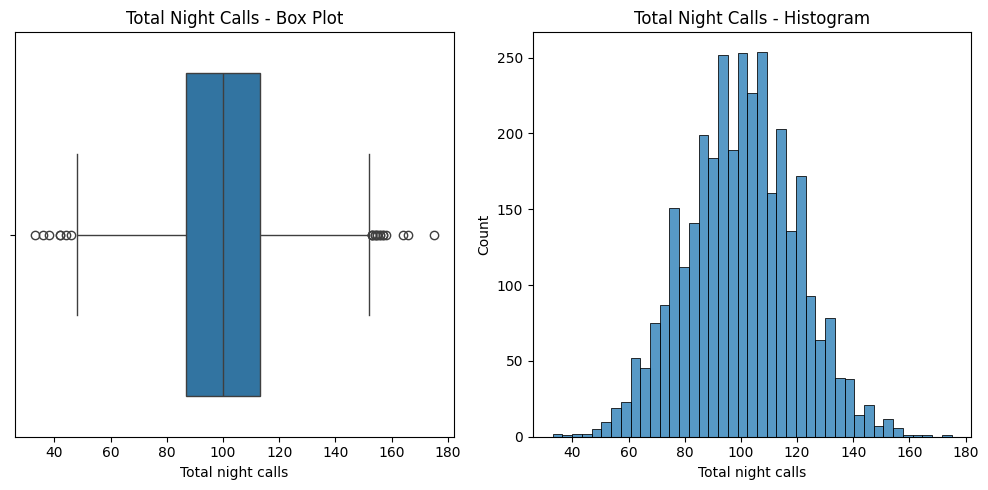

In [45]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total night calls'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total night calls'],
    ax=axes[1]
)

axes[0].set_title('Total Night Calls - Box Plot')
axes[1].set_title('Total Night Calls - Histogram')

plt.tight_layout()
plt.show()

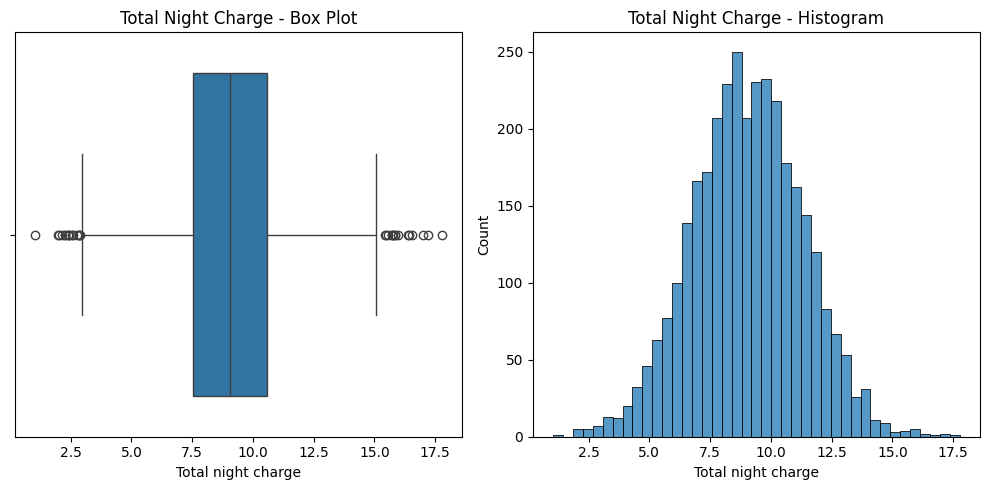

In [46]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

day_minutes = sns.boxplot(
    x=df['Total night charge'],
    ax=axes[0]
)

day_minutes_hist = sns.histplot(
    x=df['Total night charge'],
    ax=axes[1]
)

axes[0].set_title('Total Night Charge - Box Plot')
axes[1].set_title('Total Night Charge - Histogram')

plt.tight_layout()
plt.show()

In [47]:
##All categories seem to be normally distribtued. In addition, bar plots indicate that only a few have potential outliers that may need to be dealt with. Based on this, appropriate
##linear approximation models can be selected.

# TODO Create descriptive dashboard to visualize results of EDA

In [48]:
df_itl_plan = df.groupby('International plan').agg(customer_churn=('Churn','sum')).reset_index()
df_vm_plan = df.groupby('Voice mail plan').agg(customer_churn=('Churn','sum')).reset_index()

df_intl_calls_charge = df.groupby('International plan').agg(total_day_minutes=('Total day minutes', 'mean'), total_eve_minutes=('Total eve minutes', 'mean'), 
                                                       total_night_minutes=('Total night minutes', 'mean')).reset_index()

df_vm_calls_charge = df.groupby('Voice mail plan').agg(total_day_minutes=('Total day minutes', 'mean'), total_eve_minutes=('Total eve minutes', 'mean'), 
                                                       total_night_minutes=('Total night minutes', 'mean')).reset_index()

df_cs_calls = df.groupby('Customer service calls').agg(total_customers=('Churn', 'count'), customer_churn=('Churn', 'sum')).reset_index()
df_cs_calls['Churn_rate(%)'] = ((df_cs_calls['customer_churn']/df_cs_calls['total_customers']) * 100).round(2)

df_state = df.groupby('State').agg(customer_churn=('Churn', 'sum')).reset_index()

state_mapping = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevizona', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

df_state['state_full'] = df_state['State'].map(state_mapping)

C:\Users\matth\AppData\Local\Temp\ipykernel_15864\250782737.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  intl_plan = sns.barplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_15864\250782737.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['No Plan', 'International Plan'])
C:\Users\matth\AppData\Local\Temp\ipykernel_15864\250782737.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vm_plan = sns.barplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_15864\250782737.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

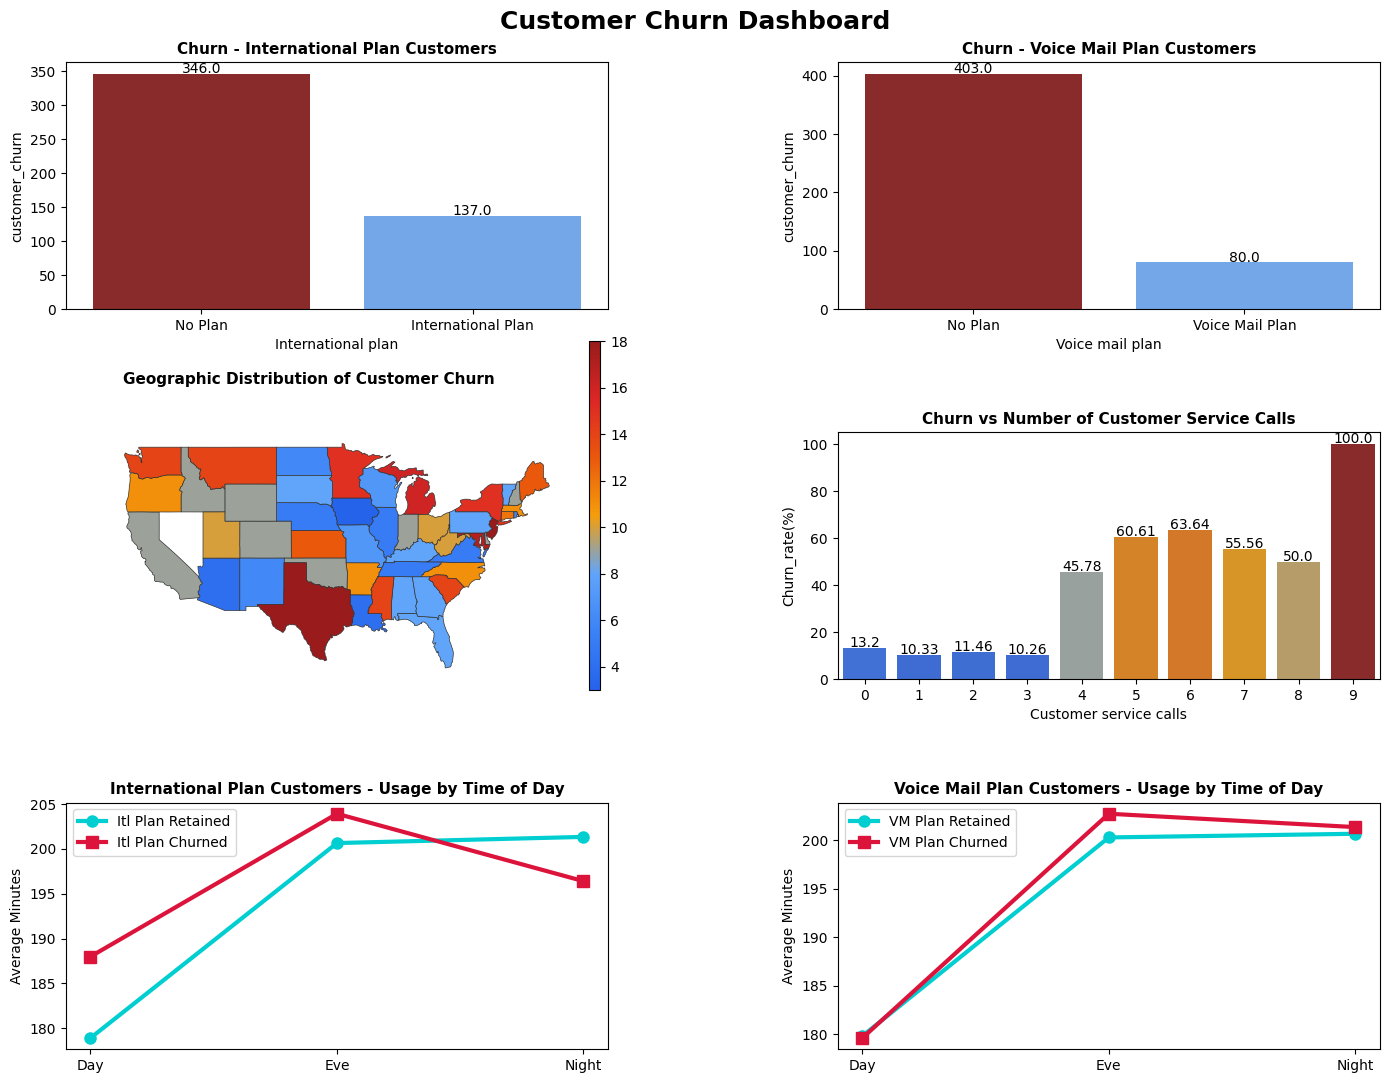

In [49]:
fig = plt.figure(figsize=(14,11))
fig.suptitle('Customer Churn Dashboard', fontsize='18', fontweight='bold')
grid_shape = (3,2)

solid_colors = [
    '#2563EB',  # 0 Calls: Rich Royal Blue (Calm)
    '#3B82F6',  # 1 Call:  Clean Medium Blue
    '#60A5FA',  # 2 Calls: Soft Solid Blue
    '#F59E0B',  # 3 Calls: Opaque Amber Orange (Warning - Highly Visible!)
    '#EA580C',  # 4 Calls: Burning Bright Orange
    '#DC2626',  # 5 Calls: Deep Pure Red (Danger)
    '#991B1B'   # 6+ Calls: Dark Crimson Red
]

churn_rates = df_cs_calls['Churn_rate(%)']
solid_color_cmap = colors.LinearSegmentedColormap.from_list("solid_color", solid_colors)
normalize = colors.Normalize(vmin=min(churn_rates), vmax=max(churn_rates))
custom_colors = [solid_color_cmap(normalize(val)) for val in churn_rates]

custom_colors_itl_plan = ['#991B1B' if x==max(df_itl_plan['customer_churn']) else '#60A5FA' for x in df_itl_plan['customer_churn']]
custom_colors_vm_plan = ['#991B1B' if x==max(df_vm_plan['customer_churn']) else '#60A5FA' for x in df_vm_plan['customer_churn']]

ax1 = plt.subplot2grid(grid_shape, (0,0))
intl_plan = sns.barplot(
    x=df_itl_plan['International plan'],
    y=df_itl_plan['customer_churn'],
    palette=custom_colors_itl_plan,
    ax=ax1
)

ax1.set_xticklabels(['No Plan', 'International Plan'])

ax2 = plt.subplot2grid(grid_shape, (0,1))
vm_plan = sns.barplot(
    x=df_vm_plan['Voice mail plan'],
    y=df_vm_plan['customer_churn'],
    palette=custom_colors_vm_plan,
    ax=ax2
)

ax2.set_xticklabels(['No Plan', 'Voice Mail Plan'])

ax3 = plt.subplot2grid(grid_shape, (1,1))
cs_calls = sns.barplot(
    x=df_cs_calls['Customer service calls'],
    y=df_cs_calls['Churn_rate(%)'],
    palette=custom_colors,
    ax=ax3
)

no_ip_day_mins = df_intl_calls_charge.loc[0, 'total_day_minutes']
no_ip_eve_mins = df_intl_calls_charge.loc[0, 'total_eve_minutes']
no_ip_night_mins = df_intl_calls_charge.loc[0, 'total_night_minutes']

no_vm_day_mins = df_vm_calls_charge.loc[0, 'total_day_minutes']
no_vm_eve_mins = df_vm_calls_charge.loc[0, 'total_eve_minutes']
no_vm_night_mins = df_vm_calls_charge.loc[0, 'total_night_minutes']

ip_day_mins = df_intl_calls_charge.loc[1, 'total_day_minutes']
ip_eve_mins = df_intl_calls_charge.loc[1, 'total_eve_minutes']
ip_night_mins = df_intl_calls_charge.loc[1, 'total_night_minutes']

vm_day_mins = df_vm_calls_charge.loc[1, 'total_day_minutes']
vm_eve_mins = df_vm_calls_charge.loc[1, 'total_eve_minutes']
vm_night_mins = df_vm_calls_charge.loc[1, 'total_night_minutes']

times_of_day = ['Day', 'Eve', 'Night']
no_ip_avg_mins = [no_ip_day_mins, no_ip_eve_mins, no_ip_night_mins]
no_vm_avg_mins = [no_vm_day_mins, no_vm_eve_mins, no_vm_night_mins]
ip_avg_mins = [ip_day_mins, ip_eve_mins, ip_night_mins]
vm_avg_mins = [vm_day_mins, vm_eve_mins, vm_night_mins]

ax4 = plt.subplot2grid(grid_shape, (2,0))
ax4.plot(
    times_of_day,
    no_ip_avg_mins,
    color='darkturquoise',
    linewidth=3,
    marker='o',
    markersize=8,
    linestyle='-',
    label='Itl Plan Retained'
)

ax4.plot(
    times_of_day,
    ip_avg_mins,
    color='crimson',
    linewidth=3,
    marker='s',
    markersize=8,
    linestyle='-',
    label='Itl Plan Churned'
)

ax5 = plt.subplot2grid(grid_shape,(2,1))
ax5.plot(
    times_of_day,
    no_vm_avg_mins,
    color='darkturquoise',
    linewidth=3,
    marker='o',
    markersize=8,
    linestyle='-',
    label='VM Plan Retained'
)

ax5.plot(
    times_of_day,
    vm_avg_mins,
    color='crimson',
    linewidth=3,
    marker='s',
    markersize=8,
    linestyle='-',
    label='VM Plan Churned'
)

us_states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
us_states = us_states[~us_states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]
merged_df = us_states.merge(df_state, left_on='name', right_on='state_full')
ax_map = plt.subplot2grid((3, 2), (1, 0))
pos = ax_map.get_position()
cax = fig.add_axes([pos.x0 + (pos.width * 0.85), pos.y0 - 0.02, 0.008, pos.height * 1.4])

merged_df.plot(
    column='customer_churn',
    cmap=solid_color_cmap,
    linewidth=0.5,
    edgecolor='#333333',
    ax=ax_map,         
    legend=True,
    cax=cax,
    legend_kwds={
        'orientation': 'vertical', 
    }
)

ax_map.set_position([pos.x0, pos.y0 - 0.08, pos.width * 1.4, pos.height * 1.3]) 

new_pos = ax_map.get_position()
fig.text(new_pos.x0 - (new_pos.x0 * 0.4), new_pos.y0 + (new_pos.height * 1.15), "Geographic Distribution of Customer Churn", fontsize=11, fontweight='bold')

ax_map.set_axis_off()

ax4.set_ylabel('Average Minutes')
ax5.set_ylabel('Average Minutes')

ax4.legend(loc='best', frameon=True)
ax5.legend(loc='best', frameon=True)

ax1.set_title('Churn - International Plan Customers', fontsize=11, fontweight='bold')
ax2.set_title('Churn - Voice Mail Plan Customers', fontsize=11, fontweight='bold')
ax3.set_title('Churn vs Number of Customer Service Calls', fontsize=11, fontweight='bold')
ax4.set_title('International Plan Customers - Usage by Time of Day', fontsize=11, fontweight='bold')
ax5.set_title('Voice Mail Plan Customers - Usage by Time of Day', fontsize=11, fontweight='bold')

plots = [intl_plan, vm_plan, cs_calls]
for i in plots:
    for b in i.patches:
        if b.get_height() != 0:
            i.annotate(b.get_height().round(2), 
                (b.get_x().round(2) + b.get_width().round(2)/ 2, b.get_height().round(2)), 
                ha = 'center', va = 'bottom', 
                xytext = (0, -1.5), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [50]:
## The above dashboard visualizes the results of the eda analysis. To summarize:
    ##Customers without an International plan churn at a much higher rate than those who do
    ##Customers without a voice mail plan churn at a much larger rate than those who do
    ##Customers churn increases drastically starting when a customer makes more than 3 customer servie calls in a month. It jumps to 100% if a customer has 9 calls
    ##Customers with international plans who churned tend to use the service more during the day and evening 
    ##Customers with voice mail plans who churned tend to use the phone more during the evening

##TODO
    ##Clean up df and start building predictive model to predict churn rates

In [51]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [52]:
##target encoding will be attempted to work with the states

In [53]:
# df_churn_map = df.groupby('State').agg(churn_rate=('Churn', 'mean')).reset_index()
# state_dict = df_churn_map.set_index('State')['churn_rate'].to_dict()
# df['State_encoded'] = df['State'].map(state_dict)
# df = df.drop(columns=(['State', 'Area code']))
# df.head()

In [54]:
corr = df.select_dtypes(include='number').corr()
corr

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
Account length,1.000000,-0.012463,0.024735,0.002918,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796,0.016541
Area code,-0.012463,1.000000,0.048551,-0.000747,-0.001994,-0.008264,-0.009646,-0.008264,0.003580,-0.011886,0.003607,-0.005825,0.016522,-0.005845,-0.018288,-0.024179,-0.018395,0.027572,0.006174
International plan,0.024735,0.048551,1.000000,0.006006,0.008745,0.049396,0.003755,0.049398,0.019100,0.006114,0.019106,-0.028905,0.012451,-0.028913,0.045871,0.017366,0.045780,-0.024522,0.259852
Voice mail plan,0.002918,-0.000747,0.006006,1.000000,0.956927,-0.001684,-0.011086,-0.001686,0.021545,-0.006444,0.021559,0.006079,0.015553,0.006064,-0.001318,0.007618,-0.001276,-0.017824,-0.102148
Number vmail messages,-0.004628,-0.001994,0.008745,0.956927,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263,-0.089728
Total day minutes,0.006216,-0.008264,0.049396,-0.001684,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423,0.205151
Total day calls,0.038470,-0.009646,0.003755,-0.011086,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942,0.018459
Total day charge,0.006214,-0.008264,0.049398,-0.001686,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427,0.205151
Total eve minutes,-0.006757,0.003580,0.019100,0.021545,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985,0.092796
Total eve calls,0.019260,-0.011886,0.006114,-0.006444,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423,0.009233


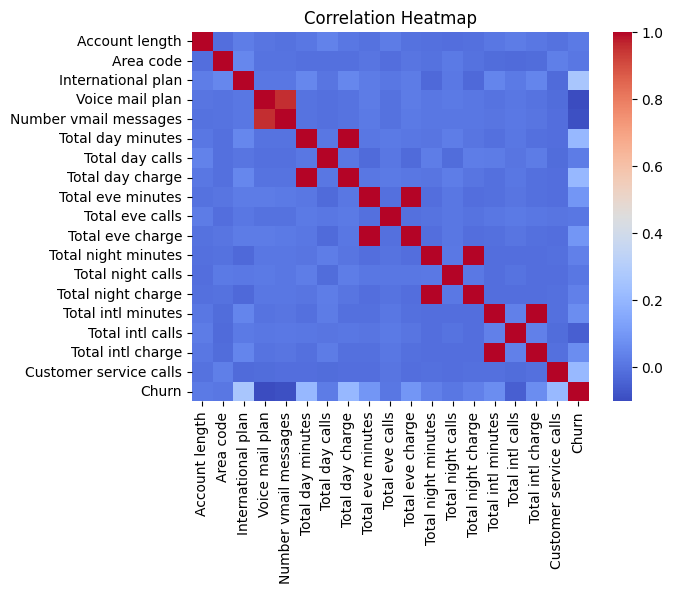

In [55]:
plt.title('Correlation Heatmap')
sns.heatmap(
    corr,
    cmap='coolwarm'
)
plt.show()

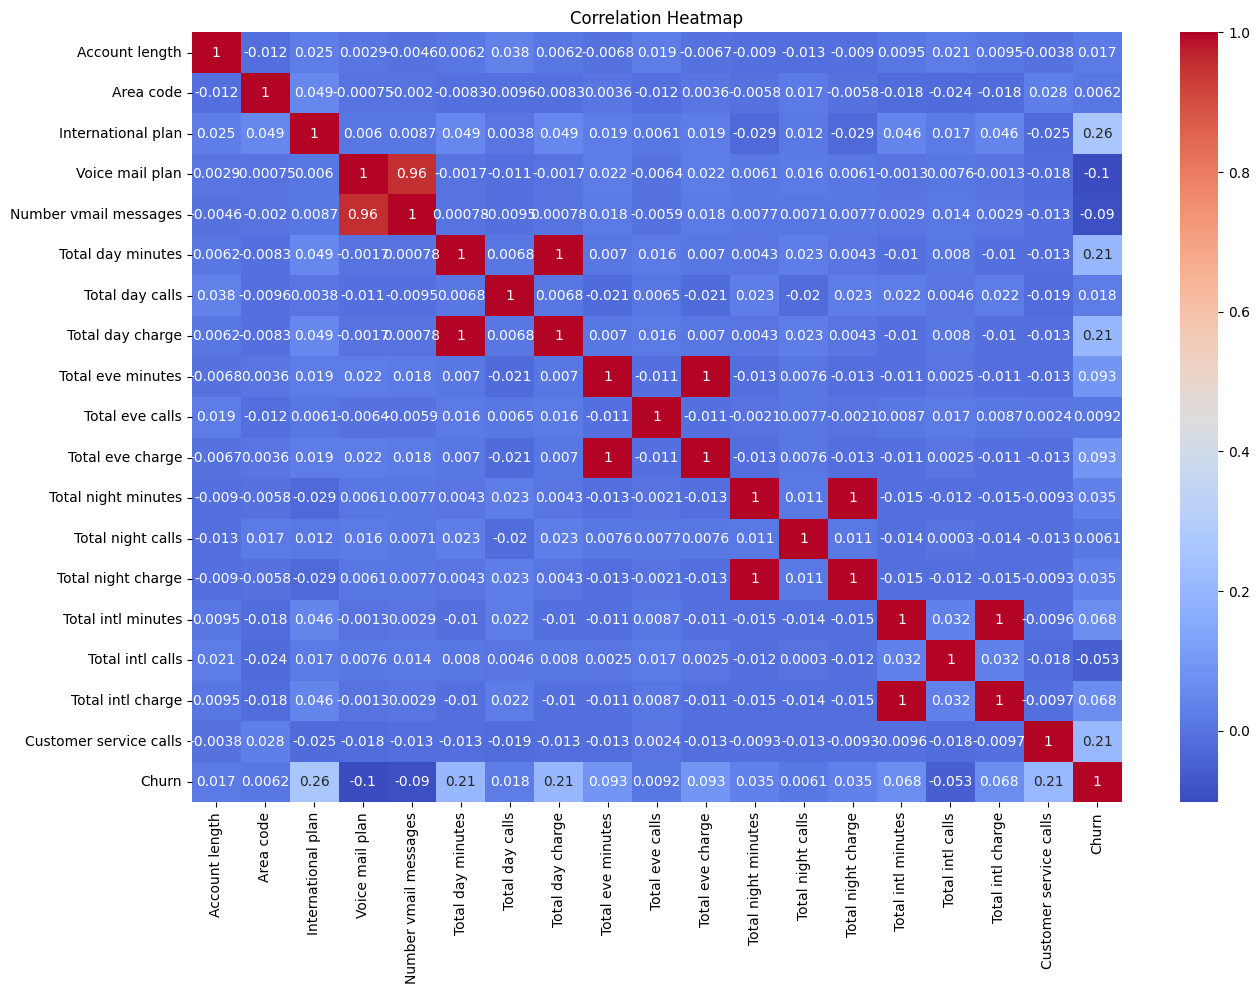

In [56]:
plt.figure(figsize=(15,10))

plt.title('Correlation Heatmap')
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [57]:
##given the results of the heatmap analysis - some columns will need to be dropped as they are too correlated with other columns. Normally, when using decision trees, this wont effect
##the math behind the prediction, but, since we are trying to get features out at the end, it is best to have only 1 correlated feature per set in the df.

cols_to_drop = ['Number vmail messages', 'Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']

df = df.drop(columns=(cols_to_drop))
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,KS,128,415,0,1,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,OH,107,415,0,1,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,NJ,137,415,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,OH,84,408,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,OK,75,415,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


In [58]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [59]:
X_build, X_val, y_build, y_val = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_build, y_build, test_size=0.25, stratify=y_build, random_state=42)

In [60]:
state_dict = y_train.groupby(X_train['State']).mean().to_dict()

X_train['State_encoded'] = X_train['State'].map(state_dict)
X_val['State_encoded'] = X_val['State'].map(state_dict)
X_test['State_encoded'] = X_test['State'].map(state_dict)

global_churn_mean = y_train.mean()

X_train['State_encoded'] = X_train['State_encoded'].fillna(global_churn_mean)
X_val['State_encoded'] = X_val['State_encoded'].fillna(global_churn_mean)
X_test['State_encoded'] = X_test['State_encoded'].fillna(global_churn_mean)

X_train = X_train.drop(columns=['State', 'Area code'])
X_val = X_val.drop(columns=['State', 'Area code'])
X_test = X_test.drop(columns=['State', 'Area code'])

In [61]:
y_test_unscaled = y_test.copy()
X_test_unscaled = X_test.copy()

In [62]:
rf = RandomForestClassifier(random_state=42)

In [63]:
rf_cv_params = {
    'n_estimators':[50, 80, 100, 200],
    'max_depth':[8, 10, 16, 24],
    'min_samples_split':[5, 10],
    'min_samples_leaf': [3, 5, 7],
    'max_features': ['sqrt']
}

In [64]:
scoring_rf = ['accuracy', 'precision', 'recall', 'f1']

In [65]:
rf_cv = GridSearchCV(rf, rf_cv_params, scoring=scoring_rf, refit='f1', n_jobs=-1)

In [66]:
rf_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [3, 5, ...], 'min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [67]:
rf_cv.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [68]:
rf_best = rf_cv.best_estimator_

In [69]:
y_rf_pred = rf_best.predict(X_val)

In [70]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_rf_pred), 2))
print('Recall Score: ', round(recall_score(y_val, y_rf_pred), 2))
print('precision Score: ', round(precision_score(y_val, y_rf_pred), 2))

Accuracy Score:  0.93
Recall Score:  0.57
precision Score:  0.92


In [71]:
##This is an incredibly uptight model. It predicts that customers churn only when it is for damn sure that they will churn. This why this model has such a good accuracy and precision score,
##It gets many positives correct, and it gets many negatives correct. But, it has a huge flaw, since it is so uptight, it misses a lot of predictions. Many customers who are a flight risk
##for churning simply aren't identified because they dont have a sign full of lights glaring at the model going, i have excessive churn symptoms. 
##This is represented in low 0.59 recall score. This would probably not be an adequate model for a business because even though it does predict churn well, it lets too many customers 
##who will churn simply walk simply because it doesnt have enough info to raise a red flag 

In [72]:
y_val_probs = rf_best.predict_proba(X_val)[:, 1]

custom_threshold = 0.4
y_custom_pred = (y_val_probs >= custom_threshold).astype(int)

print('Accuracy Score: ', round(accuracy_score(y_val, y_custom_pred), 2))
print('Recall Score: ', round(recall_score(y_val, y_custom_pred), 2))
print('precision Score: ', round(precision_score(y_val, y_custom_pred), 2))

Accuracy Score:  0.93
Recall Score:  0.66
precision Score:  0.79


In [73]:
##In an effort to try and increase the recall score, a custom prediction threshold is installed of 0.4. This doesnt do much so we will be proceeding with xgboost and then tensorflow
##as planned. Given the pitfalls that make the random forest accrue a low recall score, the xgboost should be able to make up for these.

C:\Users\matth\AppData\Local\Temp\ipykernel_15864\3579611006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  rf_importances = sns.barplot(


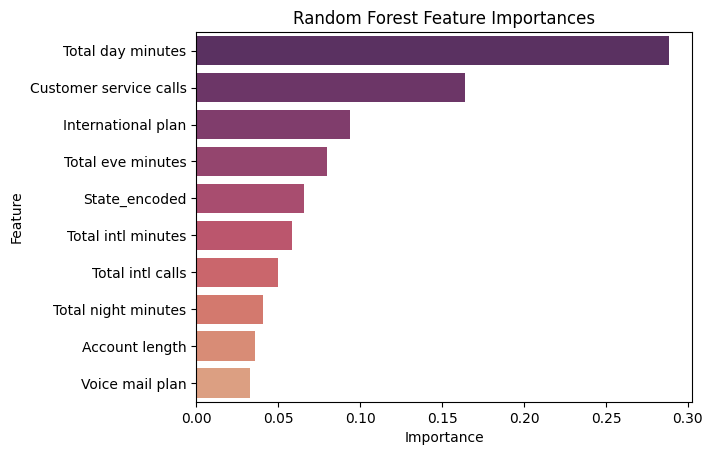

In [74]:
importances = rf_best.feature_importances_
feat_importances = pd.Series(importances, index=X_val.columns).sort_values(ascending=False)
feat_df = feat_importances.reset_index()
feat_df.columns = ['Feature', 'Importance']

rf_importances = sns.barplot(
    feat_df.head(10),
    x='Importance',
    y='Feature',
    palette='flare_r'
)

plt.title('Random Forest Feature Importances')
plt.show()

In [75]:
##currently the random forest predicts that the above features are the most important to predicting customer churn via the random forest.

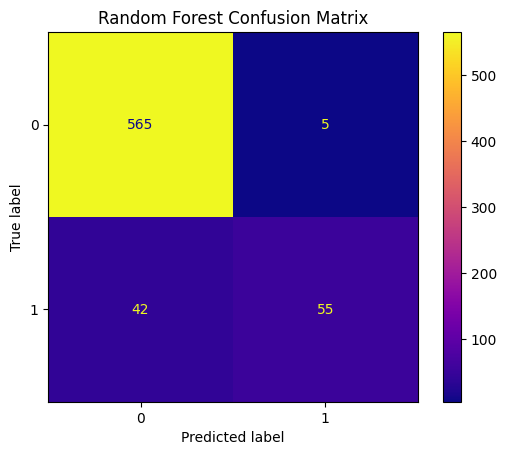

In [76]:
cm = metrics.confusion_matrix(y_val, y_rf_pred, labels=rf_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Random Forest Confusion Matrix')
plt.show()

In [77]:
##TODO Make xgb model

In [78]:
xgb = XGBClassifier(random_state=42)

In [79]:
xgb_params = {
    'max_depth':[3,4,5,7],
    'learning_rate':[0.01, 0.03, 0.06, 0.1],
    'n_estimators':[50, 75, 100]
}

In [80]:
xgb_scoring = ['accuracy', 'precision', 'recall', 'f1']

In [81]:
xgb_cv = GridSearchCV(xgb, xgb_params, scoring=xgb_scoring, refit='f1', n_jobs=-1)

In [82]:
xgb_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [83]:
xgb_cv.best_params_

{'learning_rate': 0.06, 'max_depth': 7, 'n_estimators': 100}

In [84]:
xgb_best = xgb_cv.best_estimator_

In [85]:
y_pred_xgb = xgb_best.predict(X_val)

In [86]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_pred_xgb), 2))
print('Recall Score: ', round(recall_score(y_val, y_pred_xgb), 2))
print('precision Score: ', round(precision_score(y_val, y_pred_xgb), 2))

Accuracy Score:  0.94
Recall Score:  0.72
precision Score:  0.88


In [87]:
y_val_probs = xgb_best.predict_proba(X_val)[:, 1]

custom_threshold = 0.3
y_custom_pred = (y_val_probs >= custom_threshold).astype(int)

print('Accuracy Score: ', round(accuracy_score(y_val, y_custom_pred), 2))
print('Recall Score: ', round(recall_score(y_val, y_custom_pred), 2))
print('precision Score: ', round(precision_score(y_val, y_custom_pred), 2))

Accuracy Score:  0.94
Recall Score:  0.76
precision Score:  0.79


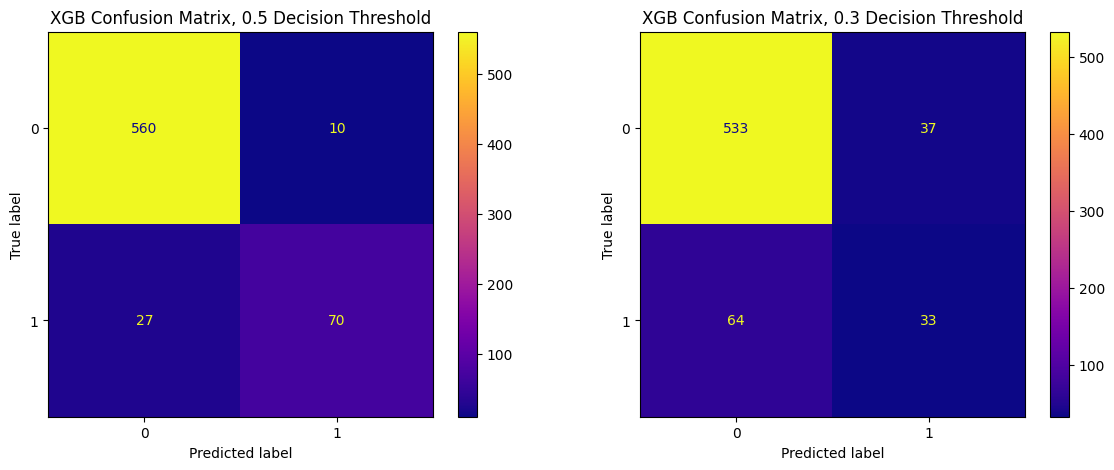

In [112]:
y_val_probs = xgb_best.predict_proba(X_val)[:, 1]

custom_threshold = 0.3
y_custom_pred_cm = (y_val_probs >= custom_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = metrics.confusion_matrix(y_val, y_pred_xgb, labels=xgb_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_best.classes_)
disp.plot(cmap='plasma', ax=axes[0])

cm = metrics.confusion_matrix(y_val, y_custom_pred_cm, labels=xgb_best.classes_)
disp_01 = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_best.classes_)
disp_01.plot(cmap='plasma', ax=axes[1])

axes[0].set_title('XGB Confusion Matrix, 0.5 Decision Threshold')
axes[1].set_title('XGB Confusion Matrix, 0.3 Decision Threshold')
plt.show()

In [ ]:
##although summary statistics look better when reducing the decision threshold, examining raw counts from the confusion matrix tell a different story. Examining the raw counts shows
##that the type 1 and type 2 errors are blowing up. Looking at the two graphs shows that sticking with the 0.5 decision threshold is the best option.

In [89]:
##TODO Develop tensor flow model

In [90]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,KS,128,415,0,1,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,OH,107,415,0,1,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,NJ,137,415,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,OH,84,408,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,OK,75,415,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


In [91]:
scaler = StandardScaler()

In [92]:
scaler_columns = ['Account length', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes',
                  'Total intl calls', 'Customer service calls']

In [93]:
X_train[scaler_columns] = scaler.fit_transform(X_train[scaler_columns])
X_val[scaler_columns] = scaler.transform(X_val[scaler_columns])
X_test[scaler_columns] = scaler.transform(X_test[scaler_columns])

In [94]:
X_train.head()

,Account length,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,State_encoded
3028,0.685030,0,0,-0.552815,-0.121234,0.627374,0.056299,1.237497,1.168841,0.814150,0.612548,-0.439899,0.243902
2290,0.285329,0,0,1.222802,0.374465,1.166188,2.007903,0.092775,0.764066,0.169090,-1.030503,1.096098,0.243902
671,-2.462616,0,1,-1.147171,0.820594,0.413807,1.257286,-1.927087,-0.551453,0.599130,0.612548,0.328099,0.184211
1713,-0.638979,0,0,-0.931041,-0.815213,-0.448295,-0.994564,0.587681,-0.652647,-0.977683,-0.619740,2.632095,0.150000
1255,-0.289241,0,0,-1.929709,1.018873,1.761822,-1.344852,0.748626,-0.551453,0.204927,-0.619740,-1.207898,0.131579


In [95]:
input_shape_dim = X_train.shape[1]
print(f"Number of input features: {input_shape_dim}")

Number of input features: 13


In [96]:
unique_classes = np.unique(y_train)

calculated_weights = compute_class_weight(
    class_weight='balanced', 
    classes=unique_classes, 
    y=y_train
)

class_weight_dict = dict(zip(unique_classes, calculated_weights))

print("=== Engineered Class Weights ===")
print(class_weight_dict)

=== Engineered Class Weights ===
{np.int64(0): np.float64(0.5845029239766082), np.int64(1): np.float64(3.458477508650519)}


Epoch 1/1500


c:\Users\matth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5913 - loss: 0.7178 - precision: 0.1780 - recall: 0.5052 - val_accuracy: 0.6207 - val_loss: 0.8664 - val_precision: 0.1579 - val_recall: 0.3711
Epoch 2/1500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7199 - loss: 0.6938 - precision: 0.2285 - recall: 0.3945 - val_accuracy: 0.7121 - val_loss: 0.8172 - val_precision: 0.1854 - val_recall: 0.2887
Epoch 3/1500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7924 - loss: 0.6768 - precision: 0.2857 - recall: 0.2907 - val_accuracy: 0.7721 - val_loss: 0.7741 - val_precision: 0.2277 - val_recall: 0.2371
Epoch 4/1500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8249 - loss: 0.6633 - precision: 0.3369 - recall: 0.2180 - val_accuracy: 0.8036 - val_loss: 0.7423 - val_precision: 0.2639 - val_recall: 0.1959
Epoch 5/1500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8379 - loss: 0.6515 - precision: 0.3871 - recall: 0.2076 - val_accuracy: 0.8141 - val_loss: 0.7203 - val_pr

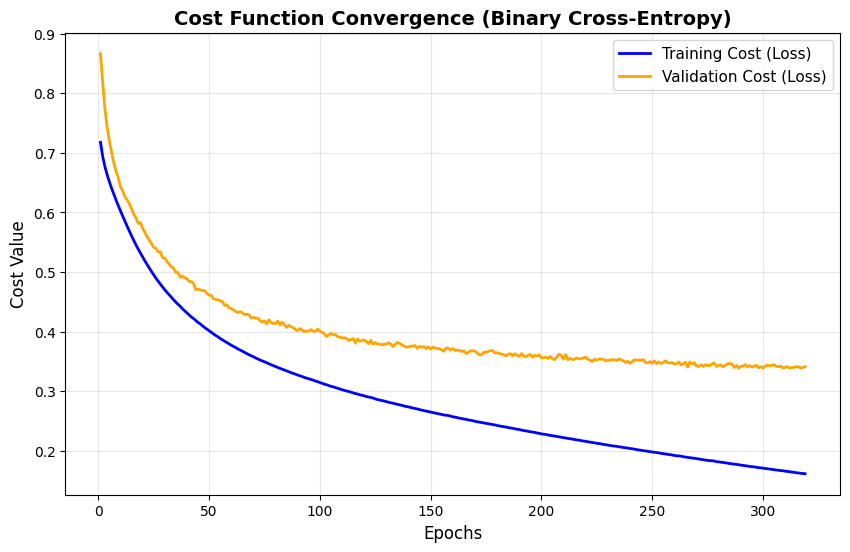

In [97]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_shape_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     
    patience=30,             
    restore_best_weights=True 
)

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 1500,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks = [early_stopping],
    verbose=1
)

training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, training_loss, label='Training Cost (Loss)', color='blue', lw=2)
plt.plot(epochs_range, validation_loss, label='Validation Cost (Loss)', color='orange', lw=2)

plt.title('Cost Function Convergence (Binary Cross-Entropy)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cost Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [98]:
raw_logits = model.predict(X_val)
y_val_prob = tf.nn.sigmoid(raw_logits).numpy()
default_threshold = 0.3
y_pred_tf = (y_val_prob >= default_threshold).astype(int)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [99]:
print('Accuracy Score: ', round(accuracy_score(y_val, y_pred_tf), 2))
print('Recall Score: ', round(recall_score(y_val, y_pred_tf), 2))
print('precision Score: ', round(precision_score(y_val, y_pred_tf), 2))

Accuracy Score:  0.81
Recall Score:  0.79
precision Score:  0.41


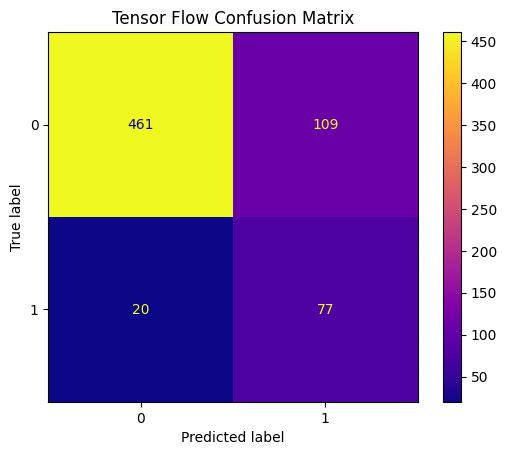

In [100]:
cm = metrics.confusion_matrix(y_val, y_pred_tf, labels=xgb_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Tensor Flow Confusion Matrix')
plt.show()

In [101]:
y_test_xgb = xgb_best.predict(X_test_unscaled)

In [102]:
print('Accuracy Score: ', round(accuracy_score(y_test_unscaled, y_test_xgb), 2))
print('Recall Score: ', round(recall_score(y_test_unscaled, y_test_xgb), 2))
print('precision Score: ', round(precision_score(y_test_unscaled, y_test_xgb), 2))

Accuracy Score:  0.96
Recall Score:  0.76
precision Score:  0.93


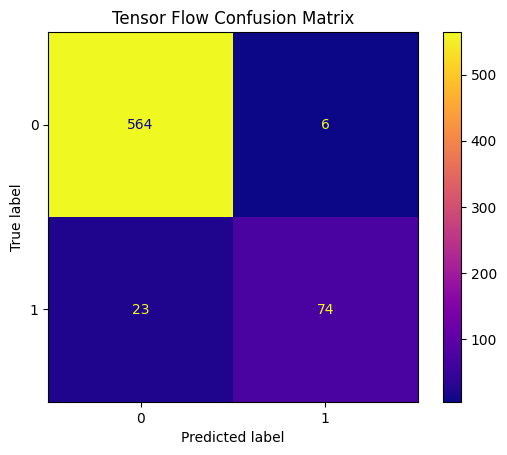

In [113]:
cm = metrics.confusion_matrix(y_test_unscaled, y_test_xgb, labels=xgb_best.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_best.classes_)
disp.plot(cmap='plasma', ax=None)

plt.title('Tensor Flow Confusion Matrix')
plt.show()

In [ ]:
##The xgb model is chosen as the 'champion' model as it stikes a balance in between low type 1 and type 2 errors, as shown above. Although type 2 is super important, and this is
##minimized with tensor flow, the model blows up in type 1 errors. Lets look at this from a business perspecitve: Type 2 errors occur when customers are going to churn, but we flag them
##as not going to churn. We want to make sure we are retaining as many customers as possible, as the subscription is important to the success of the company long term. This error would
##be minimized using the tensor flow model. However, the tensor flow model has enormous type 1 error to accompany it. This happens when a happy customer wont churn, but we predict they
##will churn anyway. In order to to try and retain a customer, the company will take some level of action, including distributing coupons, discounts, etc to try and retain them. If, we
##are constantly predicting that customers will churn, the company will be constantly issuing insetives, and be hindered by that instead of customer churn. 

##With the champion xgb model, Accuracy and precision scores above 0.9 create a very minimal type 1 error. Having a recall score of 0.76 also minimizes the type 2 error to a large extent.

##Therefore, it is my estimation that the XGB model with a decision threshold of 0.3 will be the best available model for predciting customer churn.

C:\Users\matth\AppData\Local\Temp\ipykernel_15864\2524992863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  rf_importances = sns.barplot(


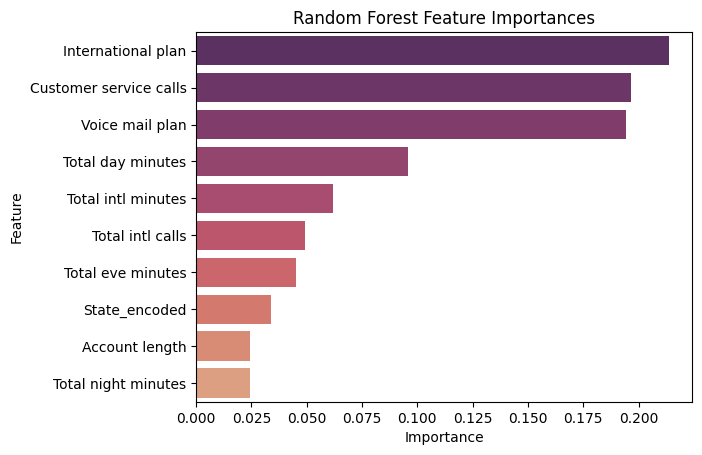

In [106]:
importances = xgb_best.feature_importances_
feat_importances = pd.Series(importances, index=X_val.columns).sort_values(ascending=False)
feat_df = feat_importances.reset_index()
feat_df.columns = ['Feature', 'Importance']

rf_importances = sns.barplot(
    feat_df.head(10),
    x='Importance',
    y='Feature',
    palette='flare_r'
)

plt.title('Random Forest Feature Importances')
plt.show()